# Raman Ramsey phase-scan analysis

This notebook ports the Qudit Ramsey phase-scan workflow to the Raman Ramsey data format.

Edit target_qubit_string and target_date_times in the next cell, then run all cells. The notebook:

1. finds matching Ramsey_qubit files in Raw_data_PD;
2. prints each wait time, pointer file, and associated raw-data paths;
3. fits every phase scan to a fixed-period cosine;
4. plots phase and contrast versus Ramsey wait time;
5. fits the contrast decay and reports the effective coherence time and Voigt linewidth.

The Raman pointer files already contain the processed phase-scan probabilities. Their last line contains the full raw-data paths; those files are used to determine the number of shots for the error bars.


In [7]:
from __future__ import annotations

import ast
import re
import warnings
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq, curve_fit

from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
rcParams['axes.grid'] = True
rcParams['font.size'] = 15


PD_DIRECTORY = Path(r"Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_PD")

target_qubit_string = "[S, 2, 0, S, 1, 0]"

target_date_times = {
    datetime(2026, 8, 11, 23, 21),
    datetime(2026, 8, 11, 23, 36),
    datetime(2026, 8, 11, 23, 43),
}

target_date_times = {
    datetime(2026, 8, 11, 23, 21),
    datetime(2026, 8, 11, 23, 36),
    datetime(2026, 8, 11, 23, 43),
}

target_date_times = {
    datetime(2026, 8, 18, 1, 28)
}

# target_qubit_string = "[S, 2, 1, S, 1, 1]"

# target_date_times = {
#     datetime(2026, 8, 12, 0, 0),
#     datetime(2026, 8, 12, 0, 18),
#     datetime(2026, 8, 12, 0, 33),
# }

PHASE_PERIOD_POINTS = 10.0
DEFAULT_SHOTS_PER_PHASE_POINT = 100
UNWRAP_PHASE = False

OUTPUT_DIRECTORY = Path.cwd() / "Raman_Ramsey_plots"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)


In [8]:
RAMSEY_FILENAME_RE = re.compile(
    r"^Ramsey_qubit_(?P<qubit>\[[^\]]+\])_WaitTime"
    r"(?P<wait>[+-]?\d+(?:\.\d+)?)us_"
    r"(?P<date>\d{8})_(?P<time>\d{4})(?:\.txt)?$"
)


@dataclass(frozen=True)
class RamseyFilename:
    qubit_string: str
    wait_time_us: float
    date_time: datetime
    path: Path


@dataclass
class RamseyScan:
    qubit_string: str
    wait_time_us: float
    date_time: datetime
    pointer_path: Path
    phase_points: np.ndarray
    probabilities: np.ndarray
    lower_errors: np.ndarray
    upper_errors: np.ndarray
    raw_file_paths: list[Path]
    shot_counts: np.ndarray


def canonicalize_qubit_string(qubit: str | Sequence[object]) -> str:
    """Return a whitespace-normalized filename-style qubit string."""
    if isinstance(qubit, str):
        text = qubit.strip()
        if text.startswith("[") and text.endswith("]"):
            text = text[1:-1]
        tokens = [token.strip().strip("'\"") for token in text.split(",")]
    else:
        tokens = [str(token).strip().strip("'\"") for token in qubit]

    if not tokens or any(not token for token in tokens):
        raise ValueError(f"Invalid qubit string: {qubit!r}")
    return f"[{', '.join(tokens)}]"


def parse_ramsey_filename(path: str | Path) -> RamseyFilename | None:
    path = Path(path)
    match = RAMSEY_FILENAME_RE.fullmatch(path.name)
    if match is None:
        return None

    date_time = datetime.strptime(
        f"{match.group('date')}_{match.group('time')}",
        "%Y%m%d_%H%M",
    )
    return RamseyFilename(
        qubit_string=canonicalize_qubit_string(match.group("qubit")),
        wait_time_us=float(match.group("wait")),
        date_time=date_time,
        path=path,
    )


def count_raw_shots(path: Path) -> int:
    """Count non-empty JSON records; each Raman raw record is one shot."""
    try:
        with path.open("r", encoding="utf-8") as file:
            return sum(bool(line.strip()) for line in file)
    except OSError as exc:
        warnings.warn(
            f"Could not count shots in {path}; using "
            f"{DEFAULT_SHOTS_PER_PHASE_POINT}. ({exc})"
        )
        return DEFAULT_SHOTS_PER_PHASE_POINT


def wilson_errors(
    probabilities: np.ndarray,
    shot_counts: np.ndarray,
    num_sd: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Return asymmetric lower/upper Wilson error-bar lengths."""
    p = np.asarray(probabilities, dtype=float)
    n = np.maximum(np.asarray(shot_counts, dtype=float), 1.0)
    z2 = num_sd**2

    center = (p + z2 / (2.0 * n)) / (1.0 + z2 / n)
    half_width = (
        np.sqrt(p * (1.0 - p) * z2 / n + z2**2 / (4.0 * n**2))
        / (1.0 + z2 / n)
    )
    lower_bound = np.clip(center - half_width, 0.0, 1.0)
    upper_bound = np.clip(center + half_width, 0.0, 1.0)
    return np.abs(p - lower_bound), np.abs(upper_bound - p)


def read_ramsey_pointer_file(metadata: RamseyFilename) -> RamseyScan:
    """
    Read phase-index/probability rows and the final raw-path list.

    Expected form:
        0,0.98
        1,0.90
        ...
        ['Z:\\path\\raw_001', 'Z:\\path\\raw_002', ...]
    """
    with metadata.path.open("r", encoding="utf-8") as file:
        lines = [line.strip() for line in file if line.strip()]

    if len(lines) < 2:
        raise ValueError("file does not contain phase data and a raw-path list")

    try:
        raw_path_values = ast.literal_eval(lines[-1])
    except (SyntaxError, ValueError) as exc:
        raise ValueError("last line is not a valid raw-path list") from exc
    if not isinstance(raw_path_values, (list, tuple)):
        raise ValueError("last line must contain a list of raw-data paths")

    phase_rows: list[tuple[float, float]] = []
    for line_number, line in enumerate(lines[:-1], start=1):
        try:
            phase_text, probability_text = line.split(",", maxsplit=1)
            phase_rows.append((float(phase_text), float(probability_text)))
        except ValueError as exc:
            raise ValueError(
                f"invalid phase/probability row at line {line_number}: {line!r}"
            ) from exc

    if not phase_rows:
        raise ValueError("file contains no phase/probability rows")

    phase_rows.sort(key=lambda row: row[0])
    phase_points = np.asarray([row[0] for row in phase_rows], dtype=float)
    probabilities = np.asarray([row[1] for row in phase_rows], dtype=float)
    if np.any((probabilities < 0.0) | (probabilities > 1.0)):
        raise ValueError("probabilities must lie between 0 and 1")

    raw_file_paths = [Path(str(value)) for value in raw_path_values]
    if len(raw_file_paths) == len(probabilities):
        shot_counts = np.asarray(
            [count_raw_shots(path) for path in raw_file_paths],
            dtype=int,
        )
    else:
        warnings.warn(
            f"{metadata.path.name}: found {len(probabilities)} phase points but "
            f"{len(raw_file_paths)} raw paths; using the default shot count."
        )
        shot_counts = np.full(
            len(probabilities),
            DEFAULT_SHOTS_PER_PHASE_POINT,
            dtype=int,
        )

    lower_errors, upper_errors = wilson_errors(probabilities, shot_counts)
    return RamseyScan(
        qubit_string=metadata.qubit_string,
        wait_time_us=metadata.wait_time_us,
        date_time=metadata.date_time,
        pointer_path=metadata.path,
        phase_points=phase_points,
        probabilities=probabilities,
        lower_errors=lower_errors,
        upper_errors=upper_errors,
        raw_file_paths=raw_file_paths,
        shot_counts=shot_counts,
    )


def search_files_by_qubit_string(
    directory: str | Path,
    qubit_string: str | Sequence[object],
    date_times: set[datetime] | Sequence[datetime] | None = None,
) -> list[RamseyScan]:
    """Load all valid pointer files matching the qubit string and datetimes."""
    directory = Path(directory)
    if not directory.is_dir():
        raise FileNotFoundError(f"Raman Ramsey pointer directory not found: {directory}")

    target_qubit = canonicalize_qubit_string(qubit_string)
    target_dates = set(date_times) if date_times is not None else None
    scans: list[RamseyScan] = []

    for path in directory.iterdir():
        if not path.is_file() or not path.name.startswith("Ramsey_qubit_"):
            continue

        metadata = parse_ramsey_filename(path)
        if metadata is None or metadata.qubit_string != target_qubit:
            continue
        if target_dates is not None and metadata.date_time not in target_dates:
            continue

        try:
            scans.append(read_ramsey_pointer_file(metadata))
        except (OSError, ValueError) as exc:
            warnings.warn(f"Skipping {path.name}: {exc}")

    scans.sort(key=lambda scan: (scan.wait_time_us, scan.date_time, scan.pointer_path.name))
    if not scans:
        dates_text = (
            "all datetimes"
            if target_dates is None
            else ", ".join(value.strftime("%Y%m%d_%H%M") for value in sorted(target_dates))
        )
        raise FileNotFoundError(
            f"No valid Raman Ramsey files matched qubit {target_qubit} "
            f"and {dates_text} in {directory}"
        )
    return scans


In [9]:
scans = search_files_by_qubit_string(
    PD_DIRECTORY,
    target_qubit_string,
    target_date_times,
)

# Parallel lists retained for familiarity with read_and_plot.ipynb.
wait_time_list = [scan.wait_time_us for scan in scans]
raw_file_paths_list = [scan.raw_file_paths for scan in scans]
ket_data_list = [scan.probabilities for scan in scans]
lower_error_list = [scan.lower_errors for scan in scans]
upper_error_list = [scan.upper_errors for scan in scans]
selected_qubit_string = scans[0].qubit_string

print(f"Qubit string: {selected_qubit_string}")
print(
    "Datetime tags: "
    + ", ".join(value.strftime("%Y%m%d_%H%M") for value in sorted(target_date_times))
)
print(f"Matched {len(scans)} Ramsey phase scans.")
print("\nWait times and corresponding raw data file paths:")

for scan in scans:
    print(f"\nWait time: {scan.wait_time_us:g} us")
    print(f"  Datetime: {scan.date_time:%Y%m%d_%H%M}")
    print(f"  Pointer file: {scan.pointer_path}")
    for raw_path in scan.raw_file_paths:
        print(f"  {raw_path}")


Qubit string: [S, 2, 0, S, 1, 0]
Datetime tags: 20260818_0128
Matched 8 Ramsey phase scans.

Wait times and corresponding raw data file paths:

Wait time: 0.1 us
  Datetime: 20260818_0128
  Pointer file: Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_PD\Ramsey_qubit_[S, 2, 0, S, 1, 0]_WaitTime0.1us_20260818_0128.txt
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copied\2026\2026_08\2026_08_18\Raman_QubitRamsey_NBOP_V2_021
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copied\2026\2026_08\2026_08_18\Raman_QubitRamsey_NBOP_V2_022
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copied\2026\2026_08\2026_08_18\Raman_QubitRamsey_NBOP_V2_023
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copied\2026\2026_08\2026_08_18\Raman_QubitRamsey_NBOP_V2_024
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copied\2026\2026_08\2026_08_18\Raman_QubitRamsey_NBOP_V2_025
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copied\2026\2026_08\2026_08_18\Raman_QubitRamsey_NBOP_V2_026
  Z:\Lab Data\Raman_Ramsey_raw_data\Raw_data_copie

In [10]:
@dataclass
class SineFit:
    scan: RamseyScan
    params: np.ndarray
    errors: np.ndarray

    @property
    def amplitude(self) -> float:
        return float(2.0 * abs(self.params[0]))

    @property
    def amplitude_error(self) -> float:
        return float(2.0 * self.errors[0])

    @property
    def phase(self) -> float:
        return float(self.params[1])

    @property
    def phase_error(self) -> float:
        return float(self.errors[1])


def sine_function(
    phase_point: np.ndarray | float,
    amplitude: float,
    phase: float,
    offset: float,
) -> np.ndarray | float:
    return amplitude * np.cos(
        2.0 * np.pi / PHASE_PERIOD_POINTS * phase_point + phase
    ) + offset


def fit_sine_curve(scan: RamseyScan) -> SineFit:
    valid = (
        np.isfinite(scan.phase_points)
        & np.isfinite(scan.probabilities)
        & np.isfinite(scan.lower_errors)
        & np.isfinite(scan.upper_errors)
    )
    x = scan.phase_points[valid]
    y = scan.probabilities[valid]
    sigma = (scan.lower_errors[valid] + scan.upper_errors[valid]) / 2.0

    if len(x) < 5:
        raise ValueError("at least five valid phase points are required")

    positive_sigma = sigma[sigma > 0.0]
    replacement = np.min(positive_sigma) if len(positive_sigma) else 1.0
    sigma = np.where(sigma > 0.0, sigma, replacement)

    omega = 2.0 * np.pi / PHASE_PERIOD_POINTS
    design = np.column_stack((np.cos(omega * x), np.sin(omega * x), np.ones_like(x)))
    cosine_coefficient, sine_coefficient, offset_guess = np.linalg.lstsq(
        design, y, rcond=None
    )[0]
    amplitude_guess = np.clip(
        np.hypot(cosine_coefficient, sine_coefficient),
        1e-6,
        0.5,
    )
    phase_guess = np.arctan2(-sine_coefficient, cosine_coefficient)
    offset_guess = np.clip(offset_guess, 0.0, 1.0)

    params, covariance = curve_fit(
        sine_function,
        x,
        y,
        p0=[amplitude_guess, phase_guess, offset_guess],
        sigma=sigma,
        absolute_sigma=True,
        bounds=([0.0, -np.pi, 0.0], [0.5, np.pi, 1.0]),
        maxfev=20_000,
    )
    errors = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    if not np.all(np.isfinite(errors)):
        raise RuntimeError("fit covariance contains non-finite uncertainties")
    return SineFit(scan=scan, params=params, errors=errors)


def fit_all_wait_times_to_sine(scans: Sequence[RamseyScan]) -> list[SineFit]:
    fits: list[SineFit] = []
    for scan in scans:
        try:
            fits.append(fit_sine_curve(scan))
        except (RuntimeError, ValueError) as exc:
            warnings.warn(
                f"Sine fit failed at {scan.wait_time_us:g} us "
                f"({scan.date_time:%Y%m%d_%H%M}): {exc}"
            )
    if not fits:
        raise RuntimeError("No Ramsey phase scan could be fit.")
    return fits


sine_fits = fit_all_wait_times_to_sine(scans)

# Familiar list names from the source notebook.
fit_wait_times_list = [fit.scan.wait_time_us for fit in sine_fits]
fit_params_list = [fit.params for fit in sine_fits]
fit_amplitudes_list = [fit.amplitude for fit in sine_fits]
fit_amplitude_errors_list = [fit.amplitude_error for fit in sine_fits]
fit_phases_list = [fit.phase for fit in sine_fits]
fit_phase_errors_list = [fit.phase_error for fit in sine_fits]

print("Fitted Ramsey phase scans:")
for fit in sine_fits:
    amplitude_parameter, phase, offset = fit.params
    print(
        f"{fit.scan.wait_time_us:8.1f} us | "
        f"A={amplitude_parameter:.4f} ± {fit.errors[0]:.4f}, "
        f"contrast={fit.amplitude:.4f} ± {fit.amplitude_error:.4f}, "
        f"phase={phase:.4f} ± {fit.phase_error:.4f} rad, "
        f"offset={offset:.4f} ± {fit.errors[2]:.4f}"
    )


Fitted Ramsey phase scans:
     0.1 us | A=0.4830 ± 0.0082, contrast=0.9659 ± 0.0164, phase=-0.0519 ± 0.0365 rad, offset=0.5042 ± 0.0076
   100.1 us | A=0.4075 ± 0.0138, contrast=0.8151 ± 0.0276, phase=-0.2552 ± 0.0482 rad, offset=0.5000 ± 0.0113
   200.1 us | A=0.3402 ± 0.0165, contrast=0.6804 ± 0.0329, phase=-0.3551 ± 0.0591 rad, offset=0.5430 ± 0.0129
   300.1 us | A=0.3252 ± 0.0169, contrast=0.6503 ± 0.0338, phase=-0.4809 ± 0.0632 rad, offset=0.5236 ± 0.0131
   400.1 us | A=0.2729 ± 0.0188, contrast=0.5457 ± 0.0377, phase=-0.7256 ± 0.0746 rad, offset=0.5309 ± 0.0139
   500.1 us | A=0.1817 ± 0.0201, contrast=0.3634 ± 0.0401, phase=-0.8135 ± 0.1140 rad, offset=0.5161 ± 0.0144
   600.1 us | A=0.1879 ± 0.0208, contrast=0.3757 ± 0.0416, phase=-1.1496 ± 0.1075 rad, offset=0.5364 ± 0.0145
   700.1 us | A=0.1317 ± 0.0214, contrast=0.2634 ± 0.0428, phase=-1.1825 ± 0.1552 rad, offset=0.5258 ± 0.0148


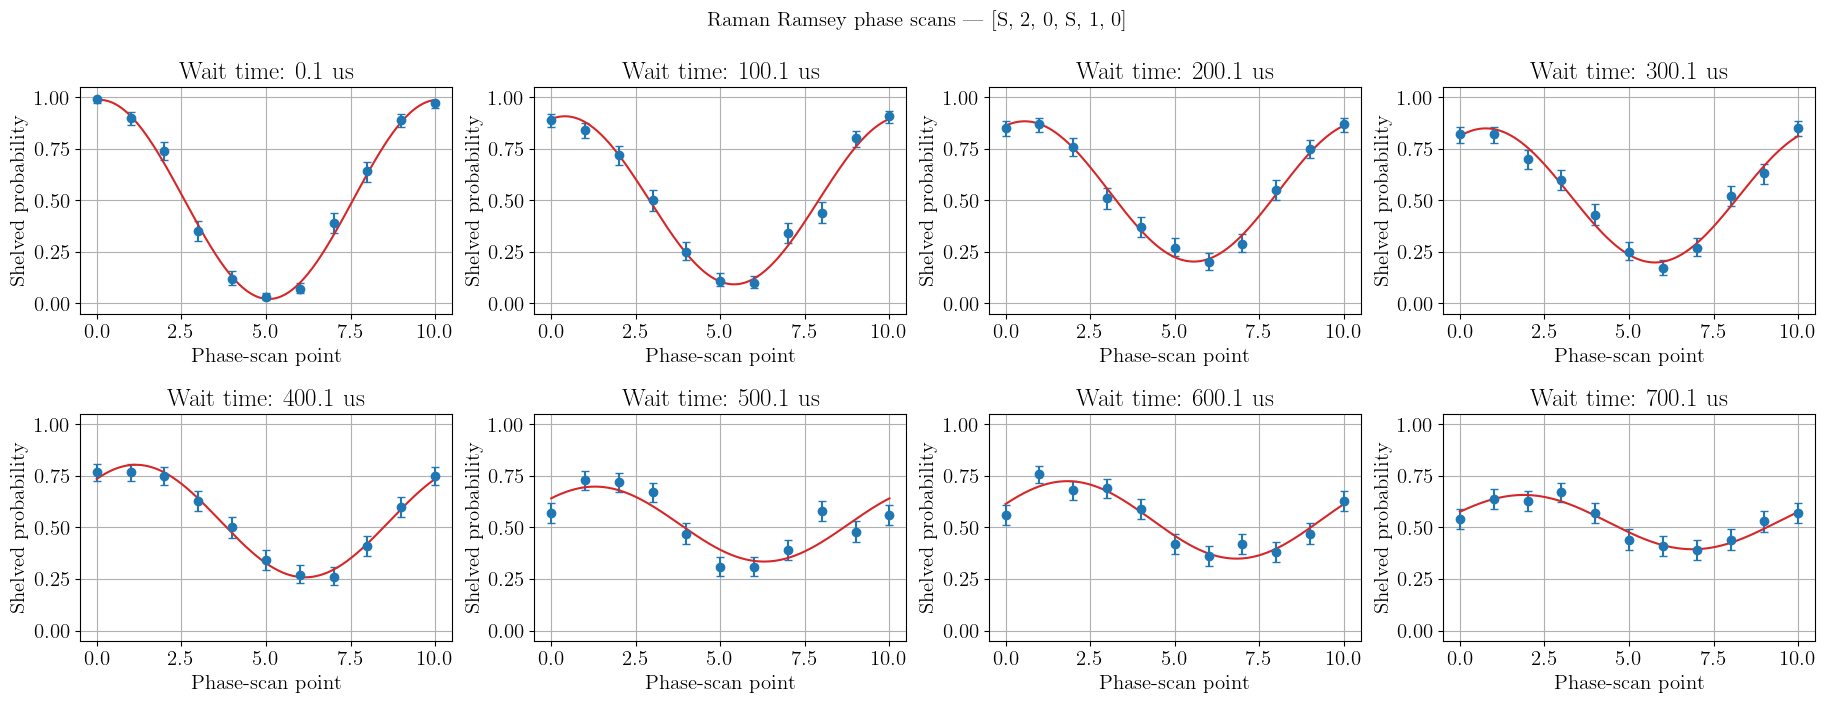

Saved phase-scan fits to: c:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Raman_Ramsey_plots_script\Raman_Ramsey_plots\S_2_0_S_1_0_phase_scan_fits.png


In [11]:
def qubit_slug(qubit_string: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", qubit_string).strip("_")


def plot_phase_scan_fits(
    scans: Sequence[RamseyScan],
    fits: Sequence[SineFit],
) -> Path:
    fit_by_pointer = {fit.scan.pointer_path: fit for fit in fits}
    number_of_columns = min(4, len(scans))
    number_of_rows = int(np.ceil(len(scans) / number_of_columns))
    fig, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(4.6 * number_of_columns, 3.6 * number_of_rows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for axis, scan in zip(axes_flat, scans):
        axis.errorbar(
            scan.phase_points,
            scan.probabilities,
            yerr=np.vstack((scan.lower_errors, scan.upper_errors)),
            fmt="o",
            capsize=3,
            # label="Data",
        )

        fit = fit_by_pointer.get(scan.pointer_path)
        if fit is not None:
            dense_phase = np.linspace(
                np.min(scan.phase_points),
                np.max(scan.phase_points),
                500,
            )
            axis.plot(
                dense_phase,
                sine_function(dense_phase, *fit.params),
                color="tab:red",
                # label=f"Fit",
            )

        axis.set_title(f"Wait time: {scan.wait_time_us:g} us")
        axis.set_xlabel("Phase-scan point")
        axis.set_ylabel("Shelved probability")
        axis.set_ylim(-0.05, 1.05)
        # axis.legend()

    for axis in axes_flat[len(scans):]:
        axis.remove()

    fig.suptitle(f"Raman Ramsey phase scans — {selected_qubit_string}", fontsize=15)
    fig.tight_layout()
    output_path = (
        OUTPUT_DIRECTORY
        / f"{qubit_slug(selected_qubit_string)}_phase_scan_fits.png"
    )
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path


phase_scan_plot_path = plot_phase_scan_fits(scans, sine_fits)
print(f"Saved phase-scan fits to: {phase_scan_plot_path}")


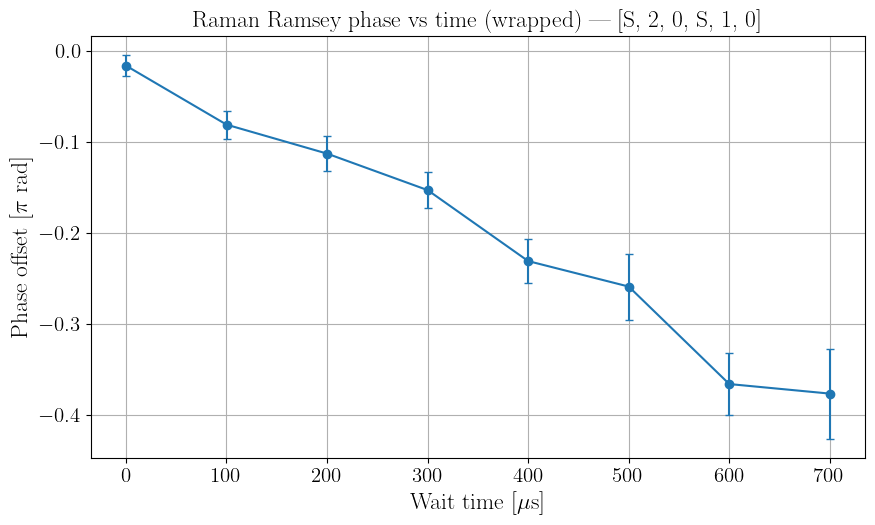

Saved phase plot to: c:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Raman_Ramsey_plots_script\Raman_Ramsey_plots\S_2_0_S_1_0_phase_vs_wait_time.png


In [12]:
def plot_phase_vs_wait_time(fits: Sequence[SineFit]) -> Path:
    ordered_fits = sorted(
        fits,
        key=lambda fit: (fit.scan.wait_time_us, fit.scan.date_time),
    )
    wait_times = np.asarray(
        [fit.scan.wait_time_us for fit in ordered_fits],
        dtype=float,
    )
    phases = np.asarray([fit.phase for fit in ordered_fits], dtype=float)
    phase_errors = np.asarray(
        [fit.phase_error for fit in ordered_fits],
        dtype=float,
    )

    if UNWRAP_PHASE:
        phases = np.unwrap(phases)

    fig, axis = plt.subplots(figsize=(9, 5.5))
    axis.errorbar(
        wait_times,
        phases / np.pi,
        yerr=phase_errors / np.pi,
        fmt="-o",
        capsize=3,
    )
    axis.set_xlabel(r"Wait time [$\mu$s]", fontsize=17)
    axis.set_ylabel(r"Phase offset [$\pi$ rad]", fontsize=17)
    phase_kind = "unwrapped" if UNWRAP_PHASE else "wrapped"
    axis.set_title(
        f"Raman Ramsey phase vs time ({phase_kind}) — {selected_qubit_string}",
        fontsize=17,
    )
    fig.tight_layout()

    output_path = (
        OUTPUT_DIRECTORY
        / f"{qubit_slug(selected_qubit_string)}_phase_vs_wait_time.png"
    )
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path


phase_plot_path = plot_phase_vs_wait_time(sine_fits)
print(f"Saved phase plot to: {phase_plot_path}")


Initial contrast: 0.96166 ± 0.016
T2 Gaussian: 1400.1 ± 656 us
T2 Lorentzian: 718.94 ± 124 us
Effective T2*: 590.89 ± 32.6 us


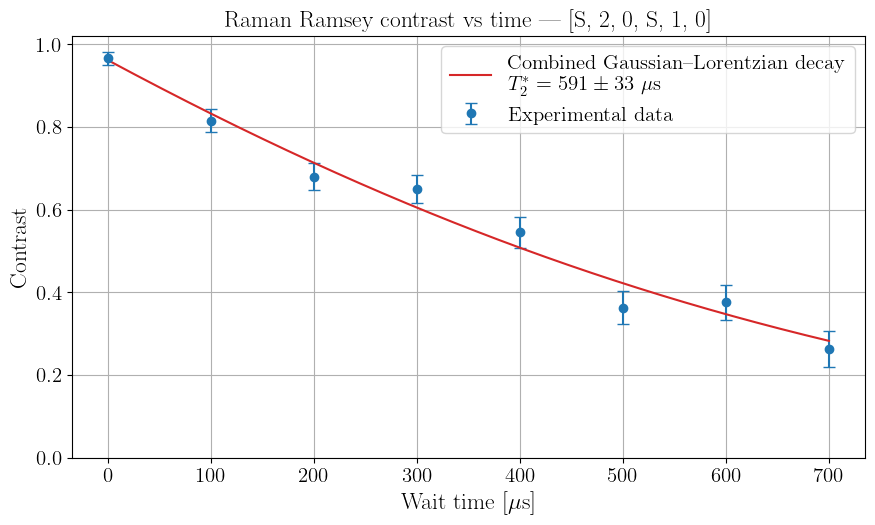

Saved contrast plot to: c:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Raman_Ramsey_plots_script\Raman_Ramsey_plots\S_2_0_S_1_0_contrast_vs_wait_time.png


In [13]:
def combined_decay(
    wait_time_us: np.ndarray | float,
    initial_contrast: float,
    t2_gaussian_us: float,
    t2_lorentzian_us: float,
) -> np.ndarray | float:
    return initial_contrast * np.exp(
        -(wait_time_us / t2_gaussian_us) ** 2
        - wait_time_us / t2_lorentzian_us
    )


@dataclass
class DecayFit:
    initial_contrast: float
    t2_gaussian_us: float
    t2_lorentzian_us: float
    covariance: np.ndarray
    effective_t2_us: float
    effective_t2_error_us: float


def calculate_effective_t2(t2_gaussian_us: float, t2_lorentzian_us: float) -> float:
    def equation(wait_time_us: float) -> float:
        return (
            np.exp(
                -(wait_time_us / t2_gaussian_us) ** 2
                - wait_time_us / t2_lorentzian_us
            )
            - 1.0 / np.e
        )

    upper = max(t2_gaussian_us, t2_lorentzian_us, 1.0)
    while equation(upper) > 0.0:
        upper *= 2.0
    return float(brentq(equation, 0.0, upper))


def effective_t2_uncertainty(
    t2_gaussian_us: float,
    t2_lorentzian_us: float,
    effective_t2_us: float,
    covariance: np.ndarray,
) -> float:
    t = effective_t2_us
    derivative_t = 2.0 * t / t2_gaussian_us**2 + 1.0 / t2_lorentzian_us
    dt_d_gaussian = (2.0 * t**2 / t2_gaussian_us**3) / derivative_t
    dt_d_lorentzian = (t / t2_lorentzian_us**2) / derivative_t
    parameter_covariance = covariance[1:3, 1:3]
    gradient = np.asarray([dt_d_gaussian, dt_d_lorentzian])
    variance = float(gradient @ parameter_covariance @ gradient)
    return float(np.sqrt(max(variance, 0.0)))


def fit_contrast_decay(fits: Sequence[SineFit]) -> DecayFit:
    wait_times = np.asarray([fit.scan.wait_time_us for fit in fits], dtype=float)
    contrasts = np.asarray([fit.amplitude for fit in fits], dtype=float)
    errors = np.asarray([fit.amplitude_error for fit in fits], dtype=float)
    valid = (
        np.isfinite(wait_times)
        & np.isfinite(contrasts)
        & np.isfinite(errors)
        & (errors > 0.0)
    )
    wait_times, contrasts, errors = (
        wait_times[valid],
        contrasts[valid],
        errors[valid],
    )
    if len(wait_times) < 4 or len(np.unique(wait_times)) < 4:
        raise ValueError("at least four distinct wait times are required")

    time_scale = max(float(np.mean(wait_times)), float(np.ptp(wait_times)), 1.0)
    params, covariance = curve_fit(
        combined_decay,
        wait_times,
        contrasts,
        p0=[min(float(np.max(contrasts)), 1.0), time_scale, time_scale],
        bounds=([0.0, 1e-12, 1e-12], [1.2, np.inf, np.inf]),
        sigma=errors,
        absolute_sigma=True,
        maxfev=50_000,
    )
    initial_contrast, t2_gaussian_us, t2_lorentzian_us = params
    effective_t2_us = calculate_effective_t2(
        t2_gaussian_us,
        t2_lorentzian_us,
    )
    effective_t2_error_us = effective_t2_uncertainty(
        t2_gaussian_us,
        t2_lorentzian_us,
        effective_t2_us,
        covariance,
    )
    return DecayFit(
        initial_contrast=float(initial_contrast),
        t2_gaussian_us=float(t2_gaussian_us),
        t2_lorentzian_us=float(t2_lorentzian_us),
        covariance=covariance,
        effective_t2_us=effective_t2_us,
        effective_t2_error_us=effective_t2_error_us,
    )


def plot_contrast_vs_wait_time(
    fits: Sequence[SineFit],
    decay_fit: DecayFit | None,
) -> Path:
    ordered_fits = sorted(
        fits,
        key=lambda fit: (fit.scan.wait_time_us, fit.scan.date_time),
    )
    wait_times = np.asarray(
        [fit.scan.wait_time_us for fit in ordered_fits],
        dtype=float,
    )
    contrasts = np.asarray([fit.amplitude for fit in ordered_fits], dtype=float)
    errors = np.asarray(
        [fit.amplitude_error for fit in ordered_fits],
        dtype=float,
    )

    fig, axis = plt.subplots(figsize=(9, 5.5))
    axis.errorbar(
        wait_times,
        contrasts,
        yerr=errors,
        fmt="o",
        capsize=4,
        label="Experimental data",
    )

    if decay_fit is not None:
        dense_wait_times = np.linspace(np.min(wait_times), np.max(wait_times), 1000)
        axis.plot(
            dense_wait_times,
            combined_decay(
                dense_wait_times,
                decay_fit.initial_contrast,
                decay_fit.t2_gaussian_us,
                decay_fit.t2_lorentzian_us,
            ),
            color="tab:red",
            label=(
                "Combined Gaussian–Lorentzian decay\n"
                f"$T_2^*={decay_fit.effective_t2_us:.0f}"
                f"\\pm{decay_fit.effective_t2_error_us:.0f}$ $\mu$s"
            ),
        )

    axis.set_xlabel(r"Wait time [$\mu$s]", fontsize=17)
    axis.set_ylabel(r"Contrast", fontsize=17)
    axis.set_title(
        f"Raman Ramsey contrast vs time — {selected_qubit_string}",
        fontsize=17,
    )
    axis.set_ylim(bottom=0.0)
    axis.legend()
    fig.tight_layout()

    output_path = (
        OUTPUT_DIRECTORY
        / f"{qubit_slug(selected_qubit_string)}_contrast_vs_wait_time.png"
    )
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path


try:
    decay_fit = fit_contrast_decay(sine_fits)
except (RuntimeError, ValueError) as exc:
    decay_fit = None
    warnings.warn(f"Contrast-decay fit failed: {exc}")

if decay_fit is not None:
    parameter_errors = np.sqrt(
        np.maximum(np.diag(decay_fit.covariance), 0.0)
    )
    print(
        f"Initial contrast: {decay_fit.initial_contrast:.5g} "
        f"± {parameter_errors[0]:.3g}"
    )
    print(
        f"T2 Gaussian: {decay_fit.t2_gaussian_us:.5g} "
        f"± {parameter_errors[1]:.3g} us"
    )
    print(
        f"T2 Lorentzian: {decay_fit.t2_lorentzian_us:.5g} "
        f"± {parameter_errors[2]:.3g} us"
    )
    print(
        f"Effective T2*: {decay_fit.effective_t2_us:.5g} "
        f"± {decay_fit.effective_t2_error_us:.3g} us"
    )

contrast_plot_path = plot_contrast_vs_wait_time(sine_fits, decay_fit)
print(f"Saved contrast plot to: {contrast_plot_path}")


In [54]:
def convert_t2_to_voigt_linewidth(
    t2_gaussian_seconds: float,
    t2_lorentzian_seconds: float,
) -> tuple[float, float, float]:
    """Convert Gaussian/Lorentzian coherence times to FWHM linewidths."""
    lorentzian_hz = 1.0 / (np.pi * t2_lorentzian_seconds)
    gaussian_hz = (
        2.0 * np.sqrt(np.log(2.0))
        / (np.pi * t2_gaussian_seconds)
    )
    voigt_hz = (
        0.5346 * lorentzian_hz
        + np.sqrt(0.2166 * lorentzian_hz**2 + gaussian_hz**2)
    )
    return gaussian_hz, lorentzian_hz, voigt_hz


if decay_fit is None:
    print("No linewidth reported because the contrast-decay fit was unavailable.")
else:
    gaussian_hz, lorentzian_hz, voigt_hz = convert_t2_to_voigt_linewidth(
        decay_fit.t2_gaussian_us * 1e-6,
        decay_fit.t2_lorentzian_us * 1e-6,
    )
    print(f"Gaussian linewidth FWHM:   {gaussian_hz:.6g} Hz")
    print(f"Lorentzian linewidth FWHM: {lorentzian_hz:.6g} Hz")
    print(f"Voigt linewidth FWHM:       {voigt_hz:.6g} Hz")
    print(f"Voigt linewidth FWHM:       {voigt_hz / 1e3:.6g} kHz")


Gaussian linewidth FWHM:   1231.4 Hz
Lorentzian linewidth FWHM: 0.000116961 Hz
Voigt linewidth FWHM:       1231.4 Hz
Voigt linewidth FWHM:       1.2314 kHz


In [20]:
(0.14*20)**2/(4*15)

0.13066666666666668

In [14]:
eta = 2*np.pi/(355e-9)

x0  = np.sqrt(1.05e-34/ 1.68e-27*2*171*2*np.pi*18e6)

eta*x0

np.float64(870223413.2144847)